# Synthetic data test

Load a synthetic two-modality tissue pair via `mgw.data` and sanity-check it.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from mgw.data import synthetic_multimodal_tissue
from mgw import plotting, metrics

### Generate

Both slices sit on the same hex grid; slice B is the same grid pushed through a small smooth
warp, so `s[i]` and `t[sigma[i]]` are the same underlying piece of tissue. Each slice is then
observed through a *different* nonlinear map of the shared latent state (cell-type mixture
`pi`, within-type trajectory `u`, global position), plus a low-rank spatial batch effect and
heteroskedastic noise that is largest at cell-type boundaries. That is the setting MGW is
meant for: two modalities, no shared features, only shared geometry.

In [2]:
data = synthetic_multimodal_tissue(
    nx=30, ny=30,      # hex grid -> n = nx*ny spots per slice
    K=4,               # cell types
    warp_amp=0.05,     # deformation slice A -> slice B
    dA=12, dB=16,        # features per modality
    seed=0,
)

s, t = data["s"], data["t"]          # spatial coords (n,2) / (m,2)
X, Z = data["X"], data["Z"]          # modality A / B features
labels, sigma = data["labels"], data["sigma"]

for k in ["s", "X", "t", "Z", "labels", "sigma"]:
    print(f"{k:7s}", data[k].shape, data[k].dtype)

s       (900, 2) float32
X       (900, 12) float32
t       (900, 2) float32
Z       (900, 16) float32
labels  (900,) int64
sigma   (900,) int64


### Spatial layout and ground-truth cell types

Both panels should show the same four soft regions (crosses = type centres). The warp is small,
so the two point clouds look nearly identical — any large apparent difference here would mean
`warp_amp` is too big for the alignment task to be meaningful.

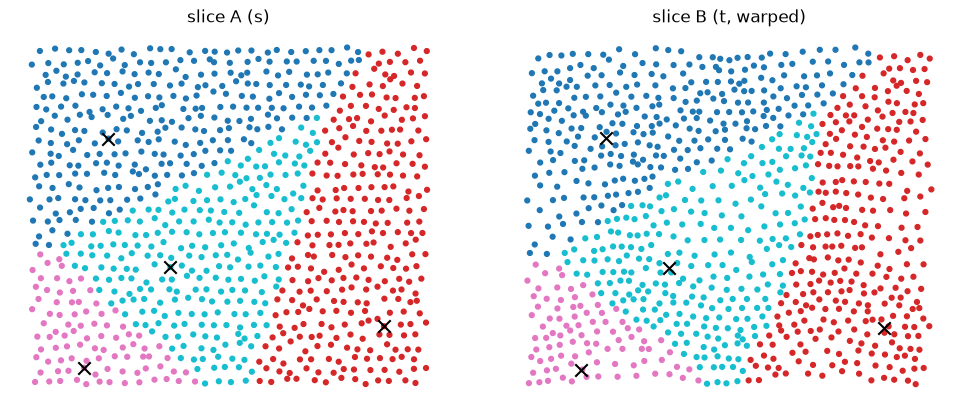

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, (coords, title) in zip(axes, [(s, "slice A (s)"), (t, "slice B (t, warped)")]):
    ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=12)
    ax.scatter(*data["centers"].T, c="k", marker="x", s=80)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()

### Feature fields

The A and B panels look unrelated feature-by-feature — that is the point. What they share is
the *layout*: patches and gradients that follow the same underlying regions. MGW has to exploit
that shared geometry, since no feature is common to both modalities.

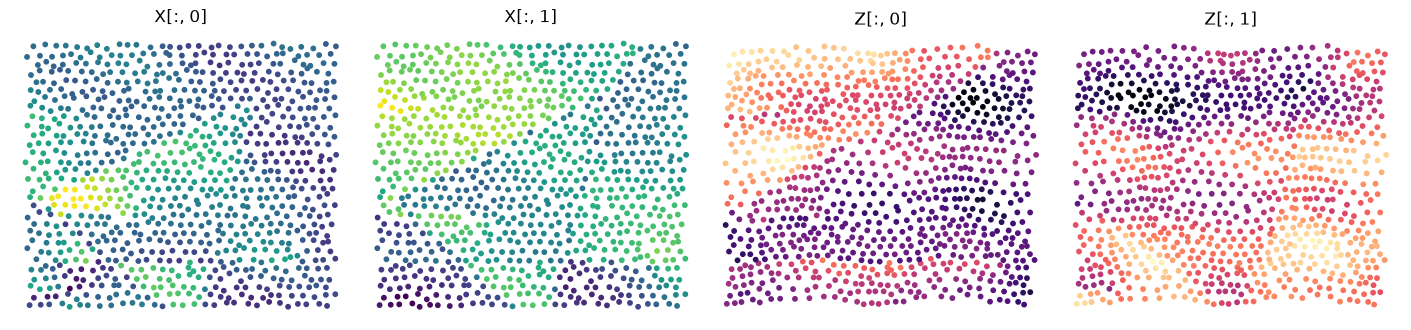

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
for j, ax in enumerate(axes[:2]):
    ax.scatter(s[:, 0], s[:, 1], c=X[:, j], cmap="viridis", s=10)
    ax.set_title(f"X[:, {j}]")
for j, ax in enumerate(axes[2:]):
    ax.scatter(t[:, 0], t[:, 1], c=Z[:, j], cmap="magma", s=10)
    ax.set_title(f"Z[:, {j}]")
for ax in axes:
    ax.set_aspect("equal"); ax.axis("off")
plt.show()

### Ground-truth correspondence

`sigma` maps each spot in A to its nearest spot in B, i.e. the alignment any method should
recover. Read the printout as the noise floor for everything below: the mean displacement
`|t[sigma] - s|` is how far a *perfect* alignment still moves a point (the warp itself), and
`unique targets < 600` means the warp makes a few B spots the nearest neighbour of several A
spots, so even the ideal map is not a clean permutation. The label agreement says the cell-type
regions really do line up under `sigma`.

In [5]:
disp = np.linalg.norm(t[sigma] - s, axis=1)
print(f"matched pairs: {len(sigma)}, unique targets: {len(np.unique(sigma))}")
print(f"displacement |t[sigma]-s|: mean {disp.mean():.4f}, max {disp.max():.4f}")
print("label agreement A vs B:", (labels == data["pi_t"].argmax(1)[sigma]).mean())

matched pairs: 900, unique targets: 743
displacement |t[sigma]-s|: mean 0.0244, max 0.0631
label agreement A vs B: 0.9755555555555555


### Preprocessing with `mgw.mgw_preprocess`

Wrap the two slices as `AnnData` (features in `.X`, coords in `.obsm["spatial"]`) and run the
standard preprocessing: unit-square coords + CCA-feeler representations.
The synthetic features are continuous and low-dimensional, so PCA/log1p are switched off
(`PCA_comp` still bounds the feeler's internal PCA, hence the small values).

In the shapes printed below, `xs`/`xs2` are the coordinates rescaled to `[0,1]²` (this is the
domain φ and ψ are trained on), `X_feat`/`Z_feat` are the normalised raw features, and
`X_rep`/`Z_rep` are what actually gets fitted: the CCA-feeler representation, here only
`CCA_comp = 2` columns because modality B has just 4 features. That low width is a real
limitation of this toy setup — it is the main suspect when the alignment below is weak.

In [6]:
import anndata as ad
import mgw.mgw as mgw

A = ad.AnnData(X=X.astype(np.float32))
A.obsm["spatial"] = s
A.obs["label"] = labels.astype(str)

B = ad.AnnData(X=Z.astype(np.float32))
B.obsm["spatial"] = t

pre = mgw.mgw_preprocess(
    A, B,
    PCA_comp=8, CCA_comp=3,
    use_cca_feeler=True,
    use_pca_X=False, use_pca_Z=False,   # features are not counts / already low-dim
    log1p_X=False, log1p_Z=False,
    verbose=True,
)

for k in ["xs", "xs2", "X_feat", "Z_feat", "X_rep", "Z_rep"]:
    print(f"{k:7s}", pre[k].shape)

[mgw.pre] PCA/raw shapes: X=(900, 12)  Z=(900, 16)
[mgw.pre] CCA feeler: PCA → small GW (fused) → barycentric → CCA
Computing PCA (8 comps)...
Computing PCA (8 comps)...
Feature shapes -> X: (900, 8) Z: (900, 8)
Feeler GW sizes: X-side 900, Z-side 900
Solving feeler feature alignment.
Computing CCA Components
CCA dims: 3  (applied to full sets)
xs      (900, 2)
xs2     (900, 2)
X_feat  (900, 12)
Z_feat  (900, 16)
X_rep   (900, 3)
Z_rep   (900, 3)


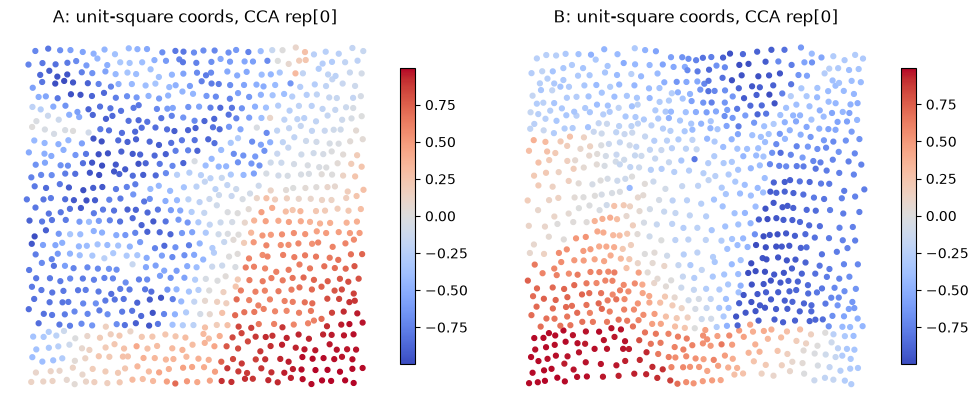

In [7]:
xs, xs2 = pre["xs"], pre["xs2"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, (coords, rep, title) in zip(
    axes, [(xs, pre["X_rep"], "A: unit-square coords, CCA rep[0]"),
           (xs2, pre["Z_rep"], "B: unit-square coords, CCA rep[0]")]):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=rep[:, 0], cmap="coolwarm", s=12)
    fig.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()

## MGW alignment

Learn the neural fields `φ, ψ : [0,1]² → features`, pull back the feature-space metric onto
each slice, turn the resulting geodesic distances into cost matrices, and solve an entropic
Gromov–Wasserstein problem → coupling `P` of shape `(n_A, n_B)`.

**What `P` is.** Not a hard one-to-one matching but a *transport plan*: `P[i, j]` is the amount
of probability mass sent from spot `i` of slice A to spot `j` of slice B. It is non-negative,
sums to 1 overall, and its margins are uniform by construction — every row sums to `1/n_A` and
every column to `1/n_B`, so each spot is fully matched and none is used twice. A perfect
one-to-one alignment would be a permutation matrix scaled by `1/n`; the entropic regularisation
`gw_params["epsilon"]` deliberately blurs it, so each row is a small distribution over nearby
candidates rather than a single spike. That is why `P.argmax(1)` is a crude summary of `P`,
and why row-weighted averages (`P @ xs2`, label posteriors) are usually the better readout.

Nothing in the objective refers to A-features and B-features jointly — GW only compares
*within*-slice distances, which is what makes an alignment possible without shared features.

In [8]:
import torch

# same defaults as demos/demo_mgw_y7.ipynb
PHI_ARC = (128, 256, 256, 128)
KNN_K = 12
DEFAULT_LR, DEFAULT_EPS, DEFAULT_ITER = 1e-3, 1e-2, 20_000
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=3000, outer_maxit=3000,
                         inner_tol=1e-7, outer_tol=1e-7, epsilon=1e-4)

# mgw_align_core uses CUDA when available and falls back to CPU.
# On CPU the two 20k-step trainings take a few minutes for 600 spots.
# phi/psi are randomly initialised; seed so reruns are reproducible
torch.manual_seed(0)
np.random.seed(0)

print("device:", "cuda" if torch.cuda.is_available() else "cpu")

device: cpu


In [9]:
out = mgw.mgw_align_core(
    pre,
    widths=PHI_ARC,
    lr=DEFAULT_LR,
    niter=DEFAULT_ITER,
    print_every=5_000,
    knn_k=KNN_K,
    geodesic_eps=DEFAULT_EPS,
    gw_params=DEFAULT_GW_PARAMS,
    device=None,          # -> cuda if available, else cpu
    verbose=True,
    plot_net=False,
    # save_dir="../experiments/", tag="synthetic_demo",  # caches phi/psi/P; a stale tag skips retraining
)

P, xs, xs2 = out["P"], out["xs"], out["xs2"]
print("coupling:", P.shape, "mass:", P.sum())

[mgw.core] device=cpu dtype=torch.float64
[mgw.core] dims: E=2, F_M=3, F_N=3
[mgw.core] training φ, ψ
[train_phi] step=5000 loss=0.010922
[train_phi] step=10000 loss=0.005260
[train_phi] step=15000 loss=0.003132
[train_phi] step=20000 loss=0.001507
[train_phi] step=5000 loss=0.006525
[train_phi] step=10000 loss=0.003911
[train_phi] step=15000 loss=0.004783
[train_phi] step=20000 loss=0.002184
[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 26.74424077339542.
Rescaling Jacobians by 6.706100485195163.
[mgw.core] cost matrices: d^2 (cost_p=2)
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 3000, 'outer_maxit': 3000, 'inner_tol': 1e-07, 'outer_tol': 1e-07, 'epsilon': 0.0001}
[mgw.core] coupling: shape=(900, 900), mass=1.000000
coupling: (900, 900) mass: 0.9999995


### Coupling

Source (left) and target (right) are drawn side by side, with a line from each A spot to its
top-weighted B partners. A good alignment gives a dense, nearly parallel band of lines
preserving the relative layout; lines that fan out and cross each other mean the coupling is
spreading mass over unrelated regions.

**Why Procrustes first.** GW matches slices by their internal distance structure only, so it
cannot tell a correct alignment from the same alignment rotated, reflected or shifted — those
are all isometries of the target and cost exactly the same. `procrustes_from_coupling(xs, xs2, P)`
removes that ambiguity: it solves for the single rigid transform (rotation `R` + translation
`tvec`, no rescaling or shearing) that best superimposes the two point clouds in the
least-squares sense, using `P` itself as soft correspondence weights, so pairs the coupling
considers matched are the pairs it tries to bring together. The returned `xs_aligned` and
`xt_aligned` are the two clouds in a common frame — purely for comparison and plotting; `P` is
unchanged. The same correction happens inside `metrics.migration_metrics` (`use_procrustes=True`),
which is why its displacement is not inflated by a global rotation the method was never
penalised for.

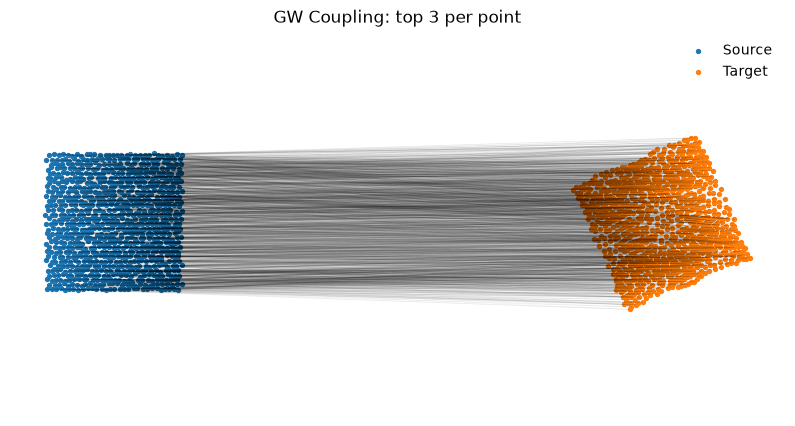

In [10]:
xs_aligned, xt_aligned, R, tvec = plotting.procrustes_from_coupling(xs, xs2, P)
plotting.plot_alignment_lines_dense(xs_aligned, xt_aligned, P, alpha=0.05)

### Accuracy against the ground truth

The synthetic pair is the one case where the true correspondence `sigma` is known, so the
coupling can be scored directly. `P` is entropic, so exact top-1 hits understate it — the
tolerant score counts a match as correct if it lands within one grid spacing of the truth.

How to read the three numbers:

- **top-1 exact match** — fraction of A spots whose largest coupling weight falls exactly on
  the true partner. Compare against the chance level `1/600 ≈ 0.0017` printed next to it.
- **within one spacing** — the same, but counting a hit if the partner is a nearest-neighbour
  of the truth. This is the fairer score for a blurred entropic coupling.
- **barycentric error** — distance between the coupling-weighted average target of each A spot
  and its true target, in unit-square units. Compare it to the grid spacing: below one spacing
  means the map is locally right, several spacings means mass is going to the wrong region.

In [11]:
match = P.argmax(1)

# one grid spacing = median nearest-neighbour distance in slice B
d_nn = np.sort(np.linalg.norm(xs2[:, None, :] - xs2[None, :, :], axis=-1), axis=1)[:, 1]
tol = np.median(d_nn)

bary = (P / P.sum(1, keepdims=True)) @ xs2           # barycentric image of each A spot
err = np.linalg.norm(bary - xs2[sigma], axis=1)

print(f"top-1 exact match  : {(match == sigma).mean():.3f}   (chance = {1/len(sigma):.4f})")
print(f"within one spacing : {(np.linalg.norm(xs2[match] - xs2[sigma], axis=1) <= tol).mean():.3f}")
print(f"barycentric error  : mean {err.mean():.4f}, median {np.median(err):.4f}  (spacing {tol:.4f})")

top-1 exact match  : 0.002   (chance = 0.0011)
within one spacing : 0.002
barycentric error  : mean 0.4953, median 0.4925  (spacing 0.0262)


### Built-in metrics

The same coupling scored with the repo's standard metrics, the ones used on real data where no
`sigma` exists:

- **expected displacement / barycentric drift** (`metrics.migration_metrics`) — how far mass
  travels under `P` after Procrustes alignment. On this dataset the two slices are the same
  grid up to a small warp, so a good alignment should move points barely more than the warp
  amplitude printed further up; the `p90`/`max` drift shows whether a few regions are badly
  misplaced or the error is spread everywhere.
- **AMI / ARI / ACC** (`metrics.ami_on_projected_labels`) — push A's cell-type labels through
  `P` onto B and compare with B's true types. This is a coarser test than spot-level accuracy:
  a coupling can score well here by matching the right *region* while getting individual spots
  wrong, so treat a high AMI with a poor barycentric error as region-level success only.

In [12]:
labels_B = data["pi_t"].argmax(1)   # cell types on slice B

mig = metrics.migration_metrics(xs, xs2, P)
print("expected displacement :", round(mig["expected_disp"], 4))
print("barycentric drift     :", {k: round(v, 4) for k, v in mig["barycentric_drift_stats"].items()})

res = metrics.ami_on_projected_labels(P, labels, labels_B)
print("projected labels      :", {k: round(float(res[k]), 3) for k in ("AMI", "ARI", "ACC")})

expected displacement : 0.5772
barycentric drift     : {'mean': 0.4967, 'median': 0.4884, 'p90': 0.8849, 'p95': 0.9355, 'max': 1.1157}
projected labels      : {'AMI': 0.347, 'ARI': 0.249, 'ACC': 0.318}


### Cell types transferred through `P`

The practical payoff of an alignment: annotations from one slice used on the other. B's types
are projected back onto A, and the printed agreement is against A's true labels. Low-confidence
spots are greyed out in the right panel — they concentrate where the coupling is uncertain,
typically at cell-type boundaries, which is exactly where the synthetic noise is largest.

agreement with true A labels: 0.313


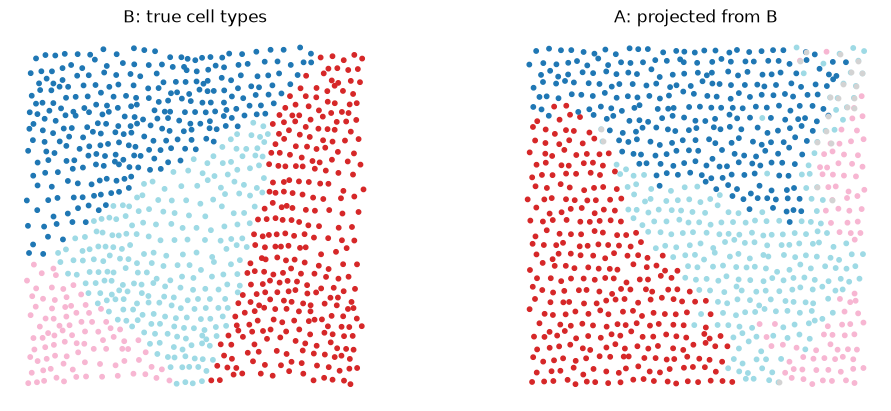

In [13]:
pred, conf, post = plotting.project_labels_via_P(P.T, labels_B, direction="A_to_B")
print("agreement with true A labels:", round(float((pred == labels).mean()), 3))

plotting.plot_projected_labels(xs2, xs, labels_B, pred, conf, conf_thresh=0.5, s=10,
                               title_A="B: true cell types", title_B="A: projected from B")

## Reading the result as a whole

This synthetic pair is a stress test, not a showcase: it is deliberately small (600 spots,
6 and 4 features) and the deformation is mild. Two failure signatures are worth telling apart:

- **Region right, spots wrong** — high AMI/ACC and good label transfer, but barycentric error
  of several grid spacings. The coupling found the correct coarse geometry and then smeared
  within it; usually a matter of the entropic regularisation `epsilon` and how informative
  `X_rep`/`Z_rep` are.
- **Globally wrong** — low AMI *and* large displacement, with the alignment lines fanning
  across the whole slice. Then the two pullback geometries did not carry enough matching
  structure to pin down the map at all.

Because `CCA_comp = 2` here, the learned metrics are close to isotropic and the two geodesic
cost matrices are nearly isometric under many maps, so GW has little reason to prefer the true
one — expect run-to-run variation with the φ/ψ initialisation (hence the seed above). Knobs
worth turning before trusting a negative result: raise `dA`/`dB` in the generator so
`PCA_comp`/`CCA_comp` can be 3 or more, try `use_cca_feeler=False` to feed the raw features,
increase `warp_amp` to break the symmetry, or vary `gw_params["epsilon"]` and `KNN_K`.